<a href="https://colab.research.google.com/github/ifekolade/Transportation-Project/blob/main/EXPLORER_NEBDHUB_Transportation_Data_Science_Project_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 **Welcome to the <font color='crimson'>** **Explorer Transportation Data Science Project! 🚗**</font>
 Hosted by the [Northeast Big Data Innovation Hub](https://nebigdatahub.org/about) & [National Student Data Corps](https://nebigdatahub.org/nsdc), in collaboration with the [U.S. Department of Transportation Federal Highway Administration](https://highways.dot.gov/).


---



## <font color='crimson'>**Milestone #1 - Data Preparation**</font>
#Exploratory Data Analysis#
  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

**Step 2:** I will be using the [NYC OpenData Motor Vehicle Collisions - Crashes dataset](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95). According to NYC Open Data, "each row represents a crash event. The Motor Vehicle Collisions data tables contain information from all police reported motor vehicle collisions in NYC."


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv")

/tmp/ipykernel_785/2598341893.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv")


In [ ]:
data.head(10)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.621790,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
5,04/26/2023,13:30,NaN,NaN,NaN,NaN,NaN,WEST 54 STREET,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4623759,Sedan,Box Truck,NaN,NaN,NaN
6,11/01/2023,7:12,NaN,NaN,NaN,NaN,NaN,HUTCHINSON RIVER PARKWAY,NaN,NaN,...,Driver Inattention/Distraction,NaN,NaN,NaN,4675709,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
7,11/01/2023,8:01,NaN,NaN,NaN,NaN,NaN,WEST 35 STREET,HENRY HUDSON RIVER,NaN,...,NaN,NaN,NaN,NaN,4675769,Sedan,NaN,NaN,NaN,NaN
8,04/26/2023,22:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61 Ed Koch queensborough bridge,...,NaN,NaN,NaN,NaN,4623865,Sedan,Pick-up Truck,NaN,NaN,NaN
9,09/11/2021,9:35,BROOKLYN,11208.0,40.667202,-73.866500,"(40.667202, -73.8665)",NaN,NaN,1211 LORING AVENUE,...,NaN,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN


#Describing the data

In [ ]:

desc_stats = data.describe()
display(desc_stats)

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,1.944002e+06,1.944002e+06,2.184015e+06,2.184002e+06,2.184033e+06,2.184033e+06,2.184033e+06,2.184033e+06,2.184033e+06,2.184033e+06,2.184033e+06
mean,4.060521e+01,-7.371123e+01,3.236187e-01,1.558149e-03,5.897942e-02,7.742557e-04,2.835214e-02,1.222509e-04,2.318752e-01,6.336901e-04,3.239523e+06
std,2.196996e+00,4.097765e+00,7.110539e-01,4.164484e-02,2.488156e-01,2.843334e-02,1.681284e-01,1.109738e-02,6.722385e-01,2.749541e-02,1.508261e+06
min,0.000000e+00,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01
25%,4.066743e+01,-7.397462e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.182129e+06
50%,4.072037e+01,-7.392690e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.728295e+06
75%,4.076961e+01,-7.386665e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.274527e+06
max,4.334444e+01,0.000000e+00,4.300000e+01,8.000000e+00,2.700000e+01,6.000000e+00,4.000000e+00,2.000000e+00,4.300000e+01,5.000000e+00,4.820622e+06




---



##<font color='crimson'> **Milestone #2 - Data Ethics, Pre-Processing, and Exploration** </font>
Assessing the dataset and finding missing values

Checking the dataset for missing values.


In [ ]:

missing_values = data.isnull().sum()

missing_values_percentage = (missing_values/ len(data)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
VEHICLE TYPE CODE 5,2174488,99.562964
CONTRIBUTING FACTOR VEHICLE 5,2174183,99.548999
VEHICLE TYPE CODE 4,2149355,98.412203
CONTRIBUTING FACTOR VEHICLE 4,2148061,98.352955
VEHICLE TYPE CODE 3,2032319,93.053493
CONTRIBUTING FACTOR VEHICLE 3,2026275,92.776757
OFF STREET NAME,1804122,82.605071
CROSS STREET NAME,833588,38.167372
ZIP CODE,673428,30.834149
BOROUGH,673157,30.821741


**Bar chart displaying the top 10 contributing factors (e.g. backing up unsafely, unsafe lane changing, etc.) to crashes within the dataset.**

/tmp/ipykernel_785/4243917548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_factors.index, y=top_factors.values, palette="magma")


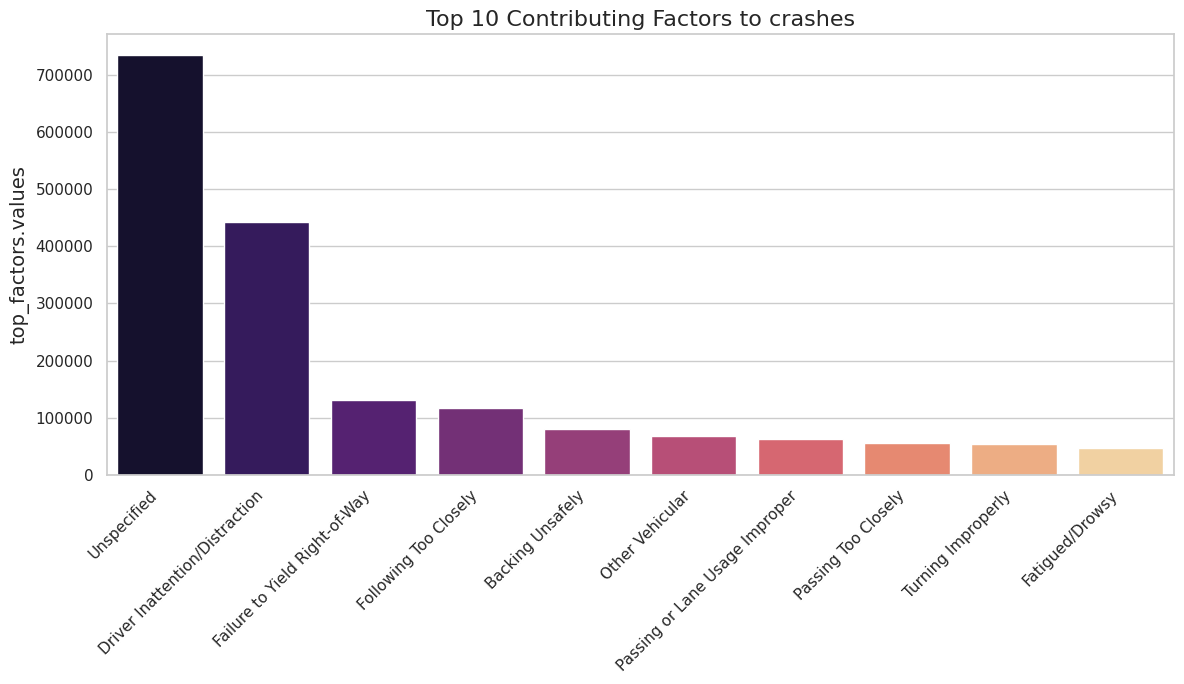

In [ ]:
top_factors = data['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(10)


plt.figure(figsize=(12, 7))

sns.barplot(x=top_factors.index, y=top_factors.values, palette="magma")
plt.title('Top 10 Contributing Factors to crashes', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('top_factors.values', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 3 contributing factors that cause the most crashes? (Besides Unspecified)

> *  Driver Inattention/ Distraction
> *  Failure to Yielf Right-of-Way
> *  Following Too Closely


Recommendations to New Drivers

>  According to the data, driver inattention/distraction is the leading cause of crashes in the city. Whether you're adjusting a GPS, taking a call, or simply distracted by the constant buzz of city life, even a momentary lapse in focus can have serious consequences. Stay alert, minimize distractions, and remember that all moments count on the road.



**Bar chart determining which vehicle types were involved in the most crashes**

/tmp/ipykernel_785/1367249658.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vehicle_types.index, y=top_vehicle_types.values, palette="cividis")


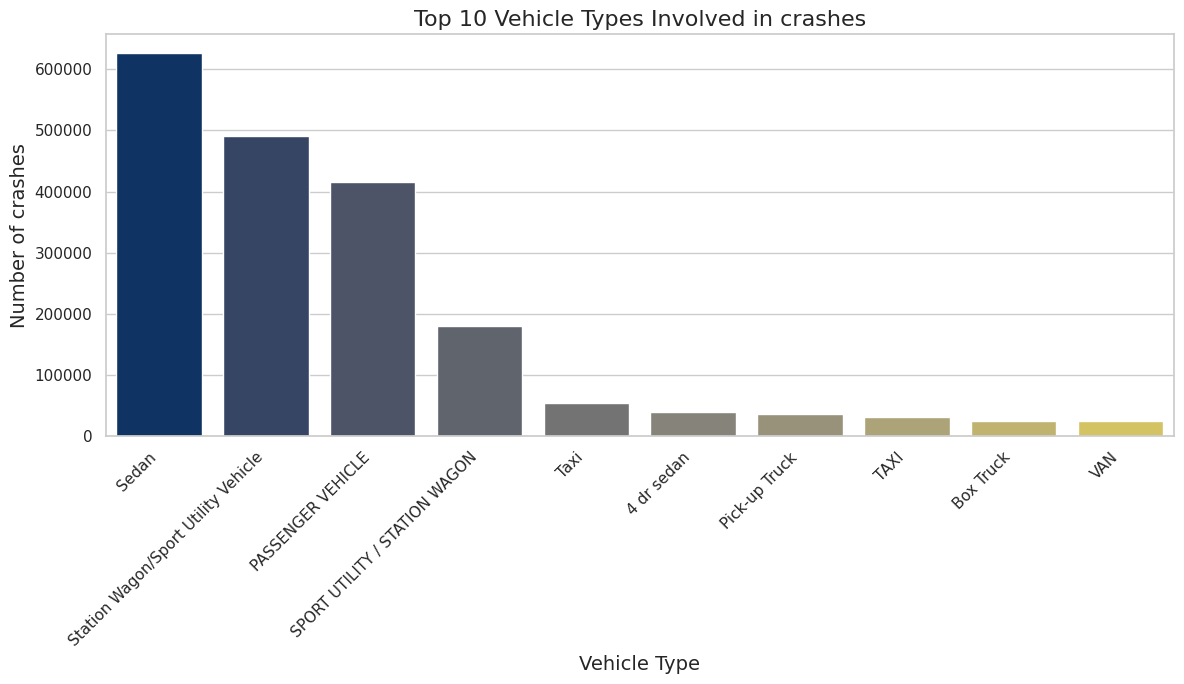

In [ ]:
top_vehicle_types = data['VEHICLE TYPE CODE 1'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_vehicle_types.index, y=top_vehicle_types.values, palette="cividis")
plt.title('Top 10 Vehicle Types Involved in crashes', fontsize=16)
plt.xlabel('Vehicle Type', fontsize=14)
plt.ylabel('Number of crashes', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 3 vehicles that were most involved in crashes


> *  Sedan
> *  Station Wagon/ Sport Utility Vehicle
> *   Passenger Vehicles







**Data** **Frame**

/tmp/ipykernel_785/1207134389.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='crash Type', data=crash_types_df, palette="mako")


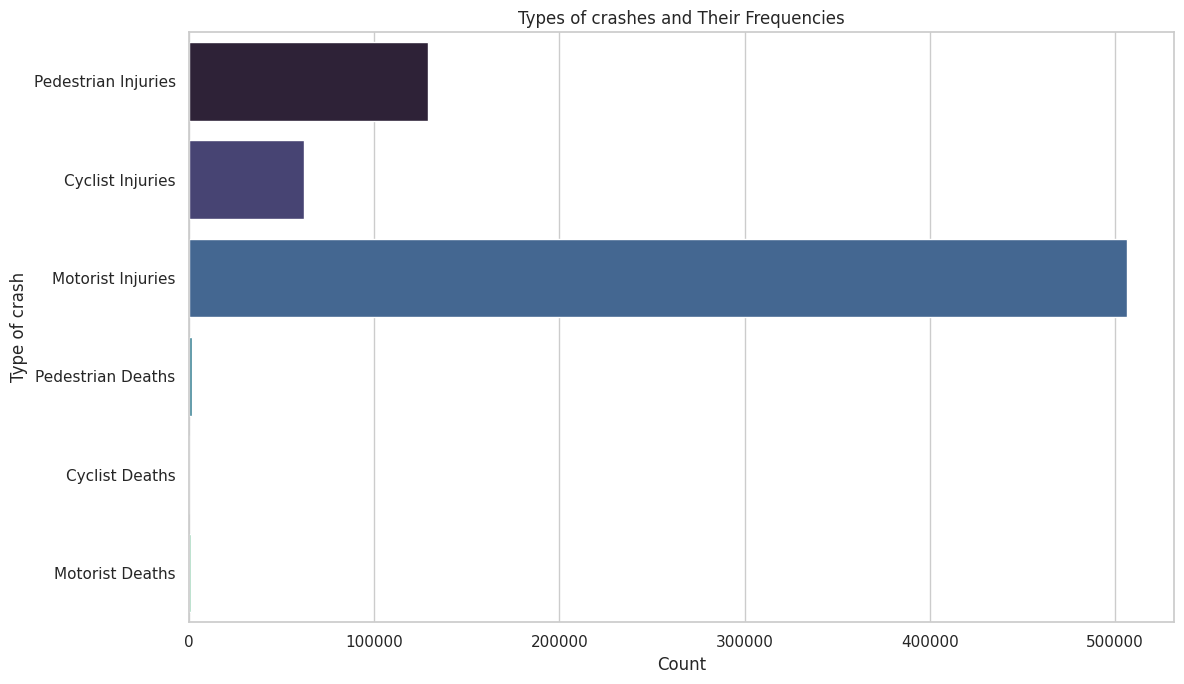

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

types_of_crashes = {
    'Pedestrian Injuries': data['NUMBER OF PEDESTRIANS INJURED'].sum(),
    'Cyclist Injuries': data['NUMBER OF CYCLIST INJURED'].sum(),
    'Motorist Injuries': data['NUMBER OF MOTORIST INJURED'].sum(),
    'Pedestrian Deaths': data['NUMBER OF PEDESTRIANS KILLED'].sum(),
    'Cyclist Deaths': data['NUMBER OF CYCLIST KILLED'].sum(),
    'Motorist Deaths': data['NUMBER OF MOTORIST KILLED'].sum()
}

crash_types_df = pd.DataFrame(list(types_of_crashes.items()), columns=['crash Type', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='crash Type', data=crash_types_df, palette="mako")
plt.title('Types of crashes and Their Frequencies')
plt.xlabel('Count')
plt.ylabel('Type of crash')
plt.tight_layout()
plt.show()

---

##<font color='crimson'> **Milestone #3 - Time Series Analysis**</font>
 Deep Dive into Time Series Analysis to better understand the data's trends over time.

**The Effect of COVID-19**

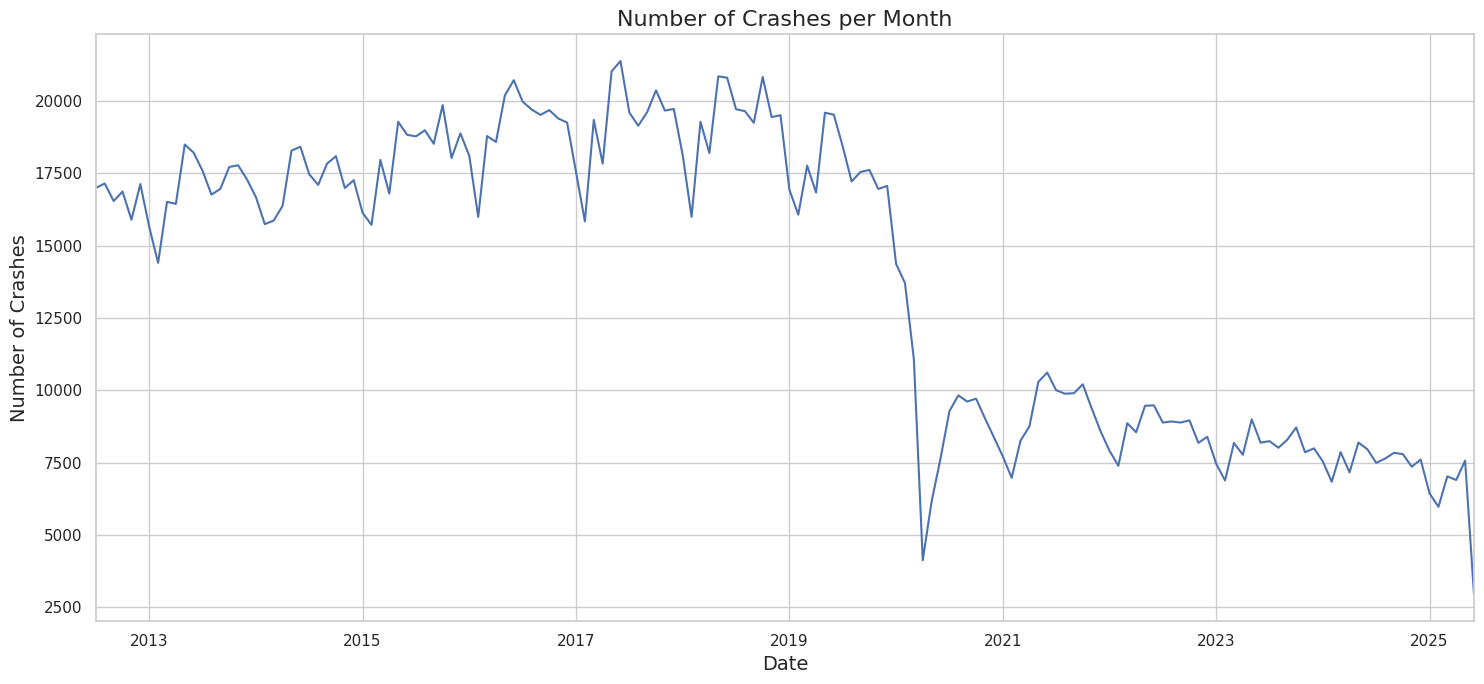

In [ ]:

data['CRASH DATE'] = pd.to_datetime(data['CRASH DATE'])


monthly_crashes = data.groupby(data['CRASH DATE'].dt.to_period("M")).size()

plt.figure(figsize=(15, 7))
monthly_crashes.plot()
plt.title('Number of Crashes per Month', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Crashes', fontsize=14)
plt.tight_layout()
plt.show()


> Clearly COVID-19 lockdown restrictions led to a dramatic decrease in the number of crashes reported.
> However it also seems that the crashes have not returned to pre-pandemic levels, suggesting less traffic overall (perhaps due to remote and hybrid working adapttiosns)



**Time series decomposition to review trends, seasonality, and residuals.**

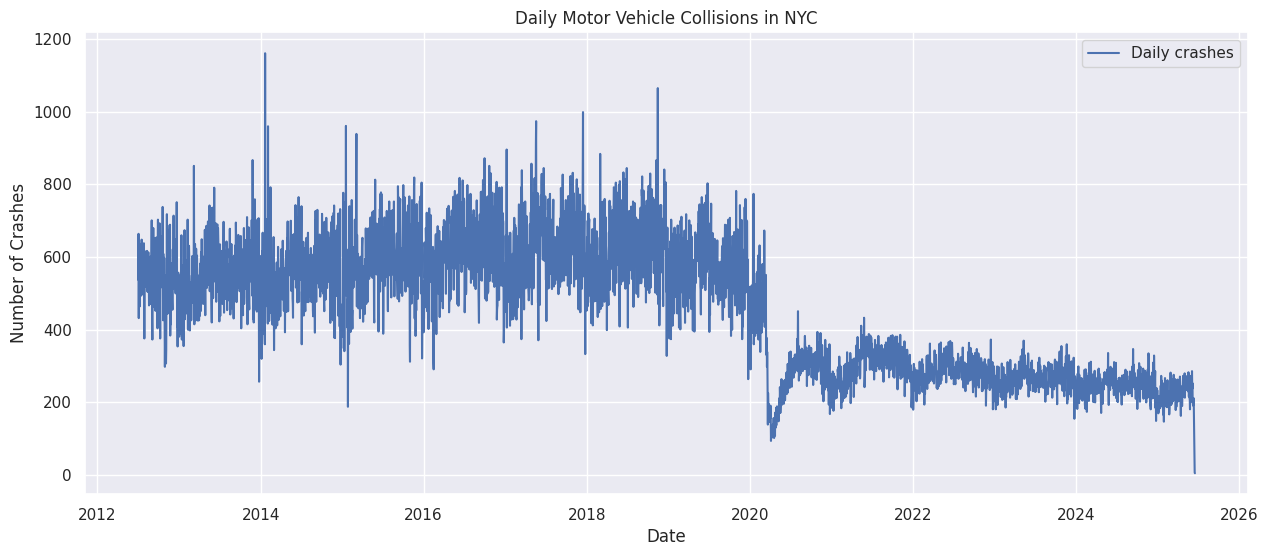

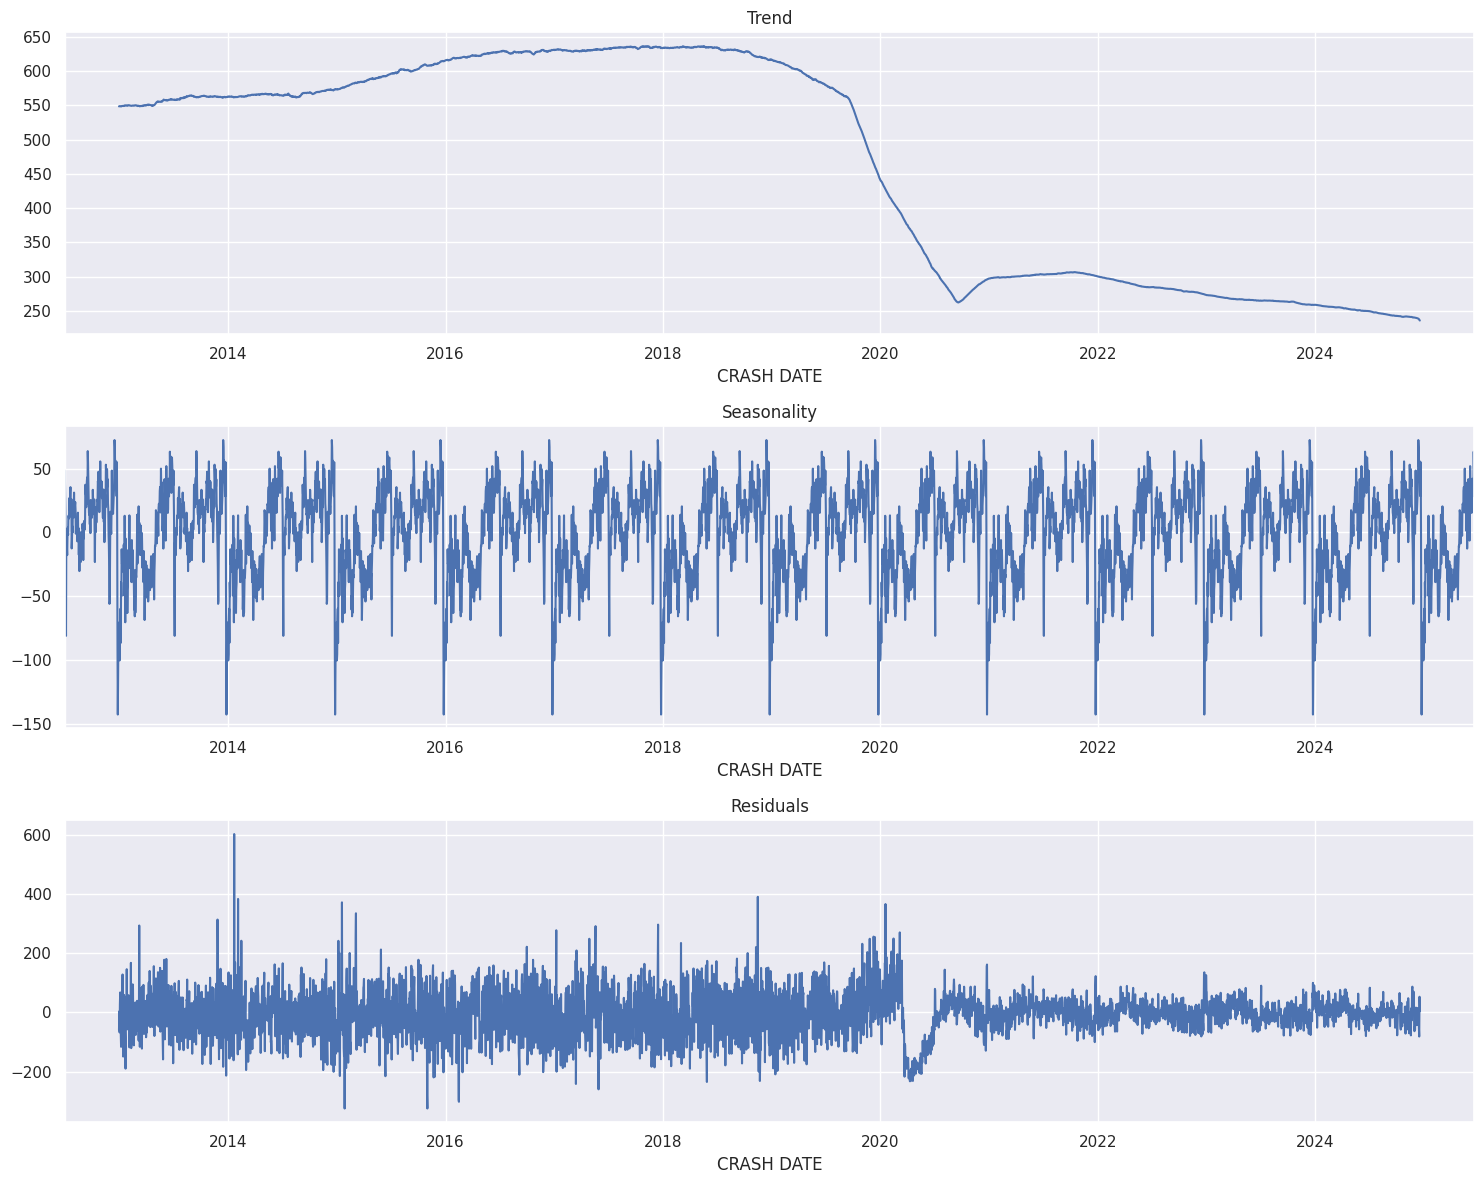

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

daily_crashes = data.groupby('CRASH DATE').size()

sns.set(style="darkgrid")

plt.figure(figsize=(15, 6))
plt.plot(daily_crashes, label='Daily crashes')
plt.title('Daily Motor Vehicle Collisions in NYC')
plt.xlabel('Date')
plt.ylabel('Number of Crashes')
plt.legend()
plt.show()

decomposition = seasonal_decompose(daily_crashes, model='additive', period=365)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))
decomposition.trend.plot(ax=ax1)
ax1.set_title('Trend')
decomposition.seasonal.plot(ax=ax2)
ax2.set_title('Seasonality')
decomposition.resid.plot(ax=ax3)
ax3.set_title('Residuals')
plt.tight_layout()
plt.show()

The visualizations above provide valuable insights into the time series of daily motor vehicle collisions in New York City:

1. Time Series Plot: This shows the number of daily crashes over time. You might observe long-term trends, seasonal patterns, or significant outliers.

2. Decomposed Components:
  
    2.1 Trend: This graph shows the long-term trend in the data, which can indicate whether crashes are increasing, decreasing, or stable over time.

    2.2 Seasonality: This reveals any regular patterns that repeat over a specific period, such as yearly. It helps identify times of the year with higher or lower crash frequencies.

    2.3 Residuals: These are the irregular components that cannot be attributed to the trend or seasonality. They might include random or unpredictable fluctuations.

---

##<font color='crimson'>**Milestone #4 - Geospatial Analysis**</font>
GOAL: The main goal of this milestone is to explore geospatial aspects of the dataset and get comfortable with regional analysis and geospatial visualizations.

/tmp/ipykernel_785/2184212468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=borough_count.index, y=borough_count.values, palette="viridis")


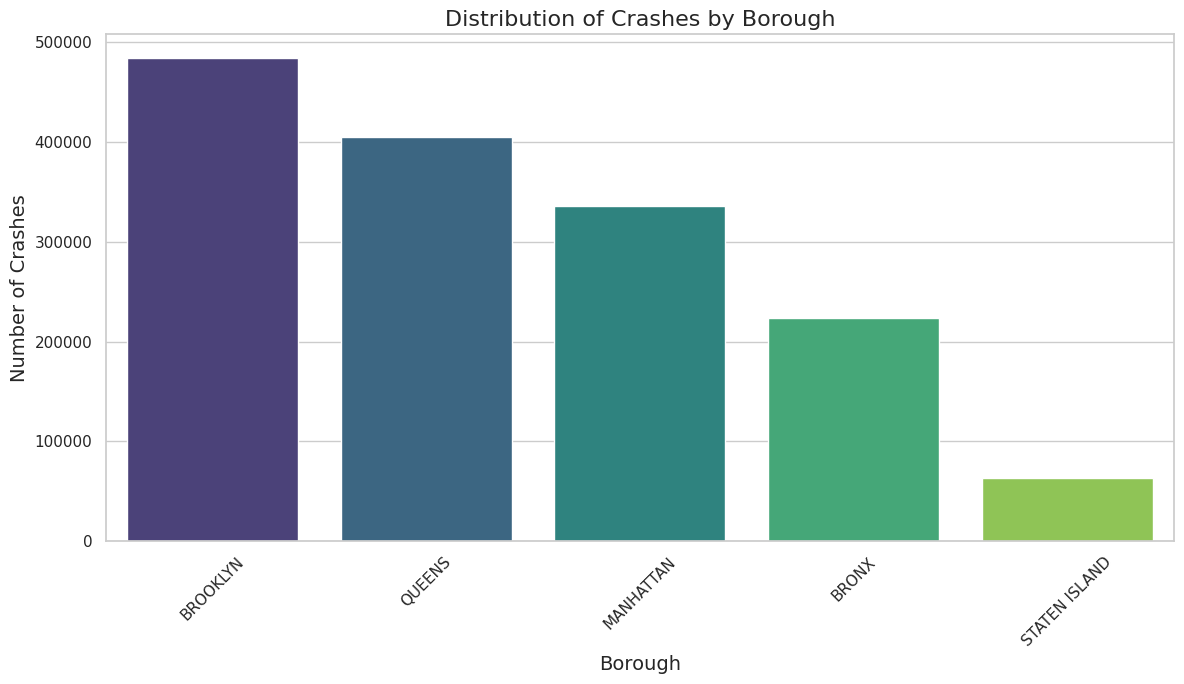

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

borough_count = data['BOROUGH'].value_counts()
sns.barplot(x=borough_count.index, y=borough_count.values, palette="viridis")
plt.title('Distribution of Crashes by Borough', fontsize=16)
plt.xlabel('Borough', fontsize=14)
plt.ylabel('Number of Crashes', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Boroughs with the highest and lowest numbers of crashes

> * Highest: Brooklyn
> * Lowest:Staten Island



#HEATMAP

In [ ]:
from folium.plugins import HeatMap

data_geo = data.dropna(subset=['LATITUDE', 'LONGITUDE'])

m = folium.Map(
    location=[40.730610, -73.935242],
    zoom_start=10,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Esri"
)

heat_data = [[row['LATITUDE'], row['LONGITUDE']] for index, row in data_geo.iterrows()]
HeatMap(heat_data, radius=8, max_zoom=13).add_to(m)

m.save("Heatmap.html")


#SEVERITY MAPPING

In [ ]:
sample_data_severity = data_geo.sample(n=1000, random_state=42)

m_severity = folium.Map(location=[40.730610, -73.935242], zoom_start=10)

for index, row in sample_data_severity.iterrows():
    if row['NUMBER OF PERSONS KILLED'] > 0:
        color = "red" # Fatalities

        folium.features.RegularPolygonMarker(
          location=[row['LATITUDE'], row['LONGITUDE']],
          number_of_sides=3,
          radius=5,
          gradient = False,
          color=color,
          fill=True,
          fill_color=color
        ).add_to(m_severity)


    elif row['NUMBER OF PERSONS INJURED'] > 0:
        color = "orange"  # Injuries
        folium.CircleMarker(
          location=[row['LATITUDE'], row['LONGITUDE']],
          radius=5,
          color=color,
          fill=True,
          fill_color=color
       ).add_to(m_severity)
    else:
        color = "blue"  # No injuries or fatalities
        folium.features.RegularPolygonMarker(
          location=[row['LATITUDE'], row['LONGITUDE']],
          number_of_sides=4,
          radius=5,
          gradient = False,
          color=color,
          fill=True,
          fill_color=color
        ).add_to(m_severity)


m_severity.save("severity.html")

---
---

# <font color='crimson'>MY RESEARCH QUESTION: How do the numbers of collisions in the Upper West side compare to the number of collisions in the rest of Upper Manhattan?

Why does this discrepancy exist?</font>


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv')


df['ZIP CODE'] = df['ZIP CODE'].astype(str)


uws_zip_codes = ['10023', '10024', '10025', '10069']


uws_crashes = df[df['ZIP CODE'].isin(uws_zip_codes)]

num_crashes_uws = len(uws_crashes)

fatal_crashes_uws = uws_crashes[uws_crashes['NUMBER OF PERSONS KILLED'] > 0]
num_fatal_crashes_uws = len(fatal_crashes_uws)

percentage_fatal_crashes_uws = (num_fatal_crashes_uws / num_crashes_uws) * 100 if num_crashes_uws > 0 else 0
num_crashes = len(uws_crashes)

print(f"Number of car crashes in the Upper West Side (ZIPs {', '.join(uws_zip_codes)}): {num_crashes}")
print(f"Percentage of crashes in Upper West side that ended in fatalities: {percentage_fatal_crashes_uws:.2f}%")

/tmp/ipykernel_785/2625810169.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv')


Number of car crashes in the Upper West Side (ZIPs 10023, 10024, 10025, 10069): 7560
Percentage of crashes in Upper West side that ended in fatalities: 0.13%


Number of car crashes in the Upper West Side (ZIPs 10023, 10024, 10025, 10069): **7560**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv')

df['ZIP CODE'] = df['ZIP CODE'].astype(str)

upper_manhattan_zips = [
    '10026', '10027', '10030', '10031', '10032', '10033',
    '10034', '10035', '10037', '10039'
]

upper_manhattan_crashes = df[df['ZIP CODE'].isin(upper_manhattan_zips)]

num_crashes_upper_manhattan = len(upper_manhattan_crashes)

fatal_crashes_upper_manhattan = upper_manhattan_crashes[upper_manhattan_crashes['NUMBER OF PERSONS KILLED'] > 0]
num_fatal_crashes_upper_manhattan = len(fatal_crashes_upper_manhattan)

percentage_fatal_crashes_upper_manhattan = (num_fatal_crashes_upper_manhattan / num_crashes_upper_manhattan) * 100 if num_crashes_upper_manhattan > 0 else 0

print(f"Number of car crashes in Upper Manhattan (ZIPs {', '.join(upper_manhattan_zips)}): {num_crashes_upper_manhattan}")
print(f"Percentage of crashes in Upper Manhattan that ended in fatalities: {percentage_fatal_crashes_upper_manhattan:.2f}%")

/tmp/ipykernel_785/3577744567.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv')


Number of car crashes in Upper Manhattan (ZIPs 10026, 10027, 10030, 10031, 10032, 10033, 10034, 10035, 10037, 10039): 16522
Percentage of crashes in Upper Manhattan that ended in fatalities: 0.10%


# DATA VISUALIZATION

(np.float64(-1.0999960664974613),
 np.float64(1.0999993102322159),
 np.float64(-1.0999993814481752),
 np.float64(1.0999999705451513))

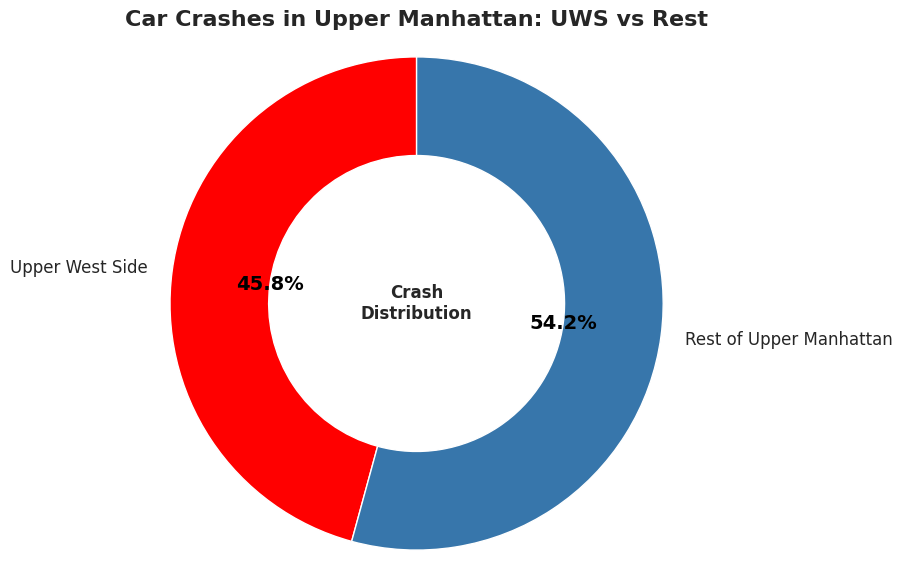

In [ ]:
import matplotlib.pyplot as plt


uws_count = len(uws_crashes)
upper_manhattan_total = len(upper_manhattan_crashes)
rest_of_upper_manhattan = upper_manhattan_total - uws_count


labels = ['Upper West Side', 'Rest of Upper Manhattan']
sizes = [uws_count, rest_of_upper_manhattan]
colors = ['red', '#3776ab']


fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)


plt.setp(autotexts, size=14, weight='bold', color='BLACK')
plt.setp(texts, size=12)

ax.text(0, 0, 'Crash\nDistribution', ha='center', va='center', fontsize=12, weight='bold')


plt.title('Car Crashes in Upper Manhattan: UWS vs Rest', fontsize=16, weight='bold')
plt.axis('equal')




---

##<font color='crimson'>**Milestone #6 - INSIGHTS AND STORYTELLING**</font>



# INSIGHTS

Contributing Factors to Upper West Side Crashes

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv"
df = pd.read_csv(file_path)

df['ZIP CODE'] = df['ZIP CODE'].astype(str)

uws_zip_codes = ['10023', '10024', '10025', '10069']

uws_crashes = df[df['ZIP CODE'].isin(uws_zip_codes)]

uws_top_factor = uws_crashes['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(6)

print("Leading causes of crashes in the Upper West Side:")
print(uws_top_factor)

/tmp/ipykernel_785/408837049.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Leading causes of crashes in the Upper West Side:
CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       3943
Driver Inattention/Distraction     975
Other Vehicular                    335
Backing Unsafely                   320
Failure to Yield Right-of-Way      318
Fatigued/Drowsy                    243
Name: count, dtype: int64


Contributing Factors to Upper Manhattan Crashes

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv"
df = pd.read_csv(file_path)

df['ZIP CODE'] = df['ZIP CODE'].astype(str)

upper_manhattan_zip_codes = [ '10026', '10027', '10030', '10031', '10032', '10033',
    '10034', '10035', '10037', '10039']

upper_manhattan_crashes = df[df['ZIP CODE'].isin(upper_manhattan_zip_codes)]

upper_manhattan_top_factor = upper_manhattan_crashes['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(6)

print("Leading causes of crashes in the rest of Upper Manhattan:")
print(upper_manhattan_top_factor)

/tmp/ipykernel_785/1477748478.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Leading causes of crashes in the rest of Upper Manhattan:
CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       9505
Driver Inattention/Distraction    1931
Other Vehicular                    617
Failure to Yield Right-of-Way      590
Backing Unsafely                   531
Fatigued/Drowsy                    491
Name: count, dtype: int64


# Time Differences

/tmp/ipython-input-1063930145.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


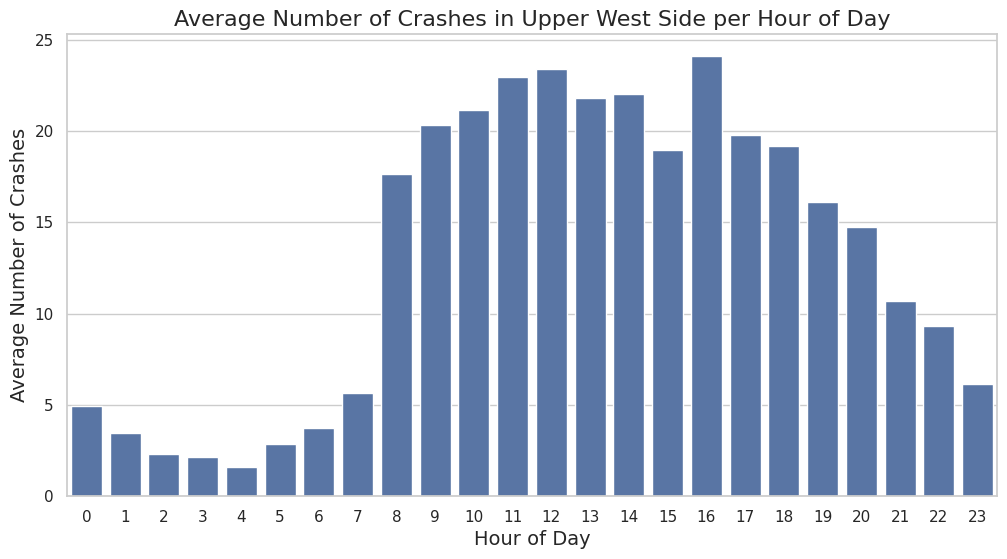

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv"
data = pd.read_csv(file_path)

data['ZIP CODE'] = data['ZIP CODE'].astype(str)

uws_zip_codes = ['10023', '10024', '10025', '10069']

uws_crashes_df = data[data['ZIP CODE'].isin(uws_zip_codes)].copy()

uws_crashes_df['CRASH TIME'] = pd.to_datetime(uws_crashes_df['CRASH TIME'], format='mixed', errors='coerce')

uws_crashes_df['Hour of Day'] = uws_crashes_df['CRASH TIME'].dt.hour

uws_crashes_df.dropna(subset=['Hour of Day'], inplace=True)

average_crashes_per_hour_uws = uws_crashes_df.groupby('Hour of Day').size() / uws_crashes_df['Hour of Day'].nunique()

plt.figure(figsize=(12, 6))
sns.barplot(x=average_crashes_per_hour_uws.index, y=average_crashes_per_hour_uws.values)
plt.title('Average Number of Crashes in Upper West Side per Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Average Number of Crashes', fontsize=14)
plt.xticks(range(0, 24))
plt.show()

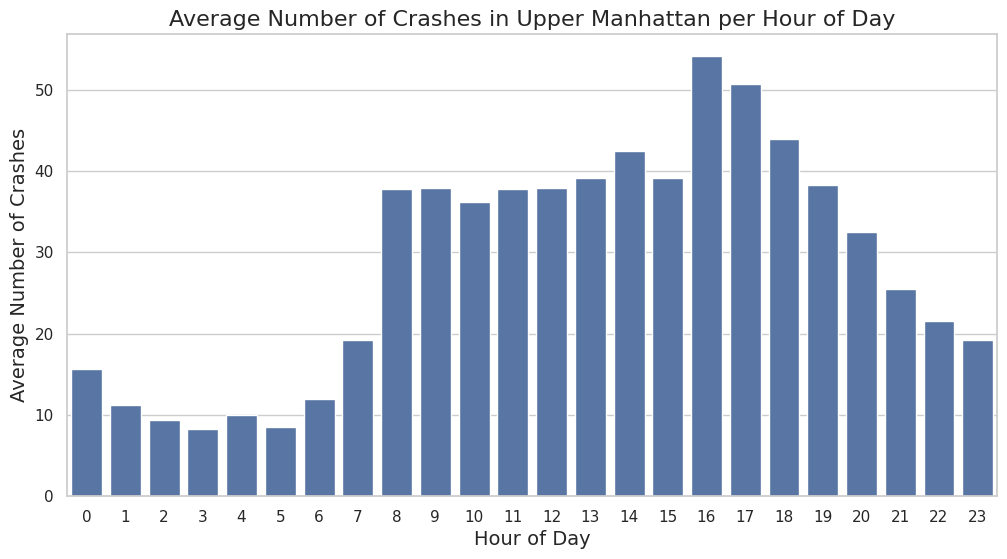

In [ ]:
upper_manhattan_zips = ['10026', '10027', '10030', '10031', '10032', '10033',
    '10034', '10035', '10037', '10039']

upper_manhattan_crashes_df = data[data['ZIP CODE'].isin(upper_manhattan_zips)].copy()

upper_manhattan_crashes_df['CRASH TIME'] = pd.to_datetime(upper_manhattan_crashes_df['CRASH TIME'], format='mixed', errors='coerce')

upper_manhattan_crashes_df['Hour of Day'] = upper_manhattan_crashes_df['CRASH TIME'].dt.hour

upper_manhattan_crashes_df.dropna(subset=['Hour of Day'], inplace=True)

average_crashes_per_hour_upper_manhattan = upper_manhattan_crashes_df.groupby('Hour of Day').size() / upper_manhattan_crashes_df['Hour of Day'].nunique()

plt.figure(figsize=(12, 6))
sns.barplot(x=average_crashes_per_hour_upper_manhattan.index, y=average_crashes_per_hour_upper_manhattan.values)
plt.title('Average Number of Crashes in Upper Manhattan per Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Average Number of Crashes', fontsize=14)
plt.xticks(range(0, 24))
plt.show()

# Insights from Charts

**Leading Crash Times in Upper West Side**
> * 16:00
> * 12:00
> * 11:00

**Leading Crash Times in the Rest of Upper Manhattan**
 > * 16:00
 > *17:00
 > *18:00


Upper West Side Crashes tend to happen earlier than crashes in Upper Manhattan.

Aside from 4pm, most crashes in the Upper West Side occur at 12pm then 11pm respectively. In Upper Manhattan, most crashes occur at 4pm then the two hours leading it.

**Potential Causes:**
- Population Size Differences
- Population Density Differences
- Driving Population Size Differences

In [ ]:
data = pd.read_excel("/content/drive/MyDrive/NewYork_DemographicsByZipCode_sample.xlsx")

Population data gotten from [New York Demographics by CUBIT](https://https://www.newyork-demographics.com/zip_codes_by_population)

In [ ]:
import pandas as pd

# data = pd.read_excel("/content/drive/MyDrive/NewYork_DemographicsByZipCode_sample.xlsx")

data['Geography'] = data['Geography'].astype(str)

upper_manhattan_zip_codes = [ '10026', '10027', '10030', '10031', '10032', '10033',
    '10034', '10035', '10037', '10039']

upper_manhattan_population_df = data[data['Geography'].isin(upper_manhattan_zip_codes)]

upper_manhattan_population = upper_manhattan_population_df['Population'].sum()

print("Population of Upper Manhattan:")
print(upper_manhattan_population)

Population of Upper Manhattan:
20230


In [ ]:
import pandas as pd


data['Geography'] = data['Geography'].astype(str)

uws_zip_codes = ['10023', '10024', '10025', '10069']

uws_population_df = data[data['Geography'].isin(uws_zip_codes)]

uws_population = uws_population_df['Population'].sum()

print("Population of Upper West Side:")
print(uws_population)

Population of Upper West Side:
8092


In [ ]:
#Number of Crashes compared to population

import matplotlib.pyplot as plt



Population Density of Upper West Side according to [The Bridget Harvey team](https://bridgetharveyteam.com/)

136,816.4

Population Density of Upper Manhattan

123,658.5



Although the Upper West Side has a lower population than Upper Manhattan, it has a higher population density. This might provide reasoning for its higher percentage of fatal crashes.  

---

# **Crashes, Zip codes and population**


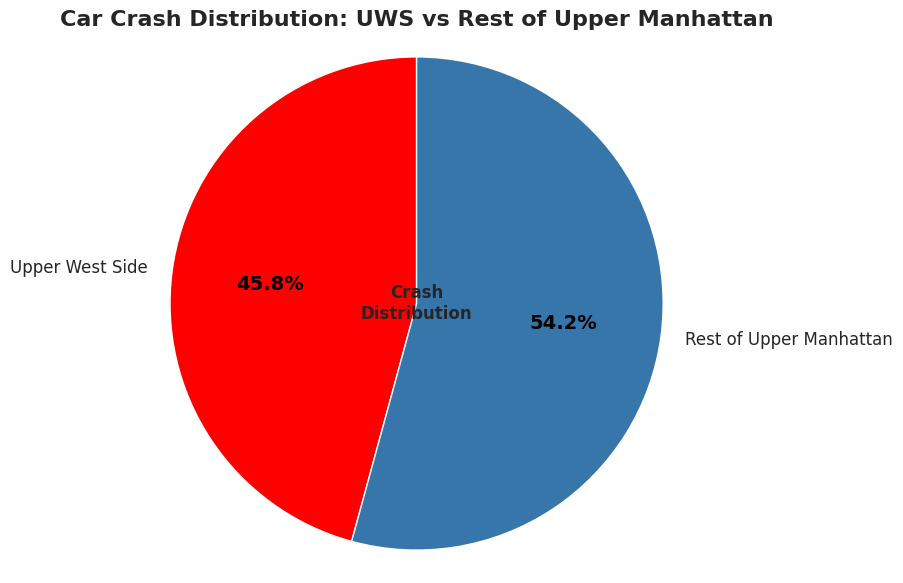

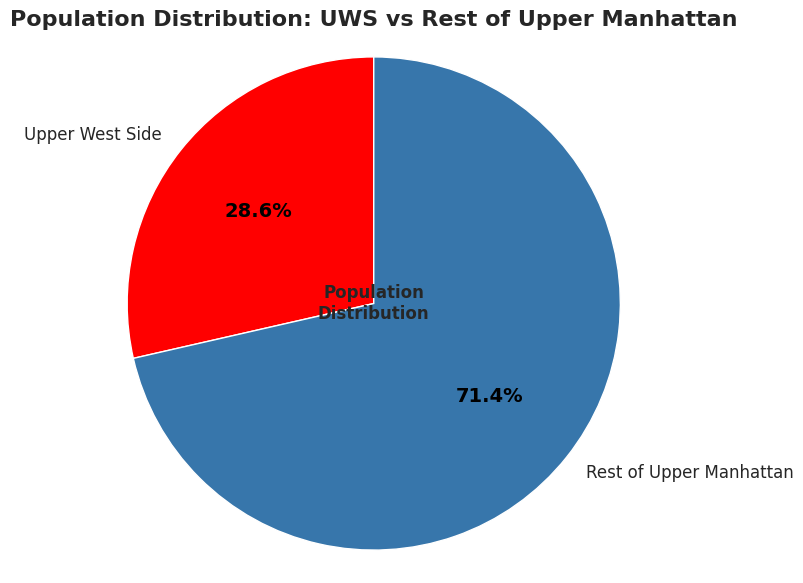

In [ ]:
import matplotlib.pyplot as plt

labels_crashes = ['Upper West Side', 'Rest of Upper Manhattan']
sizes_crashes = [uws_count, upper_manhattan_total - uws_count]
colors_crashes = ['red', '#3776ab']

fig1, ax1 = plt.subplots(figsize=(7, 7))
wedges1, texts1, autotexts1 = ax1.pie(
    sizes_crashes,
    labels=labels_crashes,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_crashes,
)

plt.setp(autotexts1, size=14, weight='bold', color='BLACK')
plt.setp(texts1, size=12)
ax1.text(0, 0, 'Crash\nDistribution', ha='center', va='center', fontsize=12, weight='bold')
plt.title('Car Crash Distribution: UWS vs Rest of Upper Manhattan', fontsize=16, weight='bold')
plt.axis('equal')
plt.show()


labels_population = ['Upper West Side', 'Rest of Upper Manhattan']
sizes_population = [uws_population, upper_manhattan_population]
colors_population = ['red', '#3776ab']

fig2, ax2 = plt.subplots(figsize=(7, 7))
wedges2, texts2, autotexts2 = ax2.pie(
    sizes_population,
    labels=labels_population,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_population,
)

plt.setp(autotexts2, size=14, weight='bold', color='BLACK')
plt.setp(texts2, size=12)
ax2.text(0, 0, 'Population\nDistribution', ha='center', va='center', fontsize=12, weight='bold')
plt.title('Population Distribution: UWS vs Rest of Upper Manhattan', fontsize=16, weight='bold')
plt.axis('equal')
plt.show()

In [ ]:
population_data_df = pd.read_excel("/content/drive/MyDrive/NewYork_DemographicsByZipCode_sample.xlsx")
uws_zip_codes = ['10023', '10024', '10025', '10069']
uws_population_df = population_data_df[population_data_df['Geography'].astype(str).isin(uws_zip_codes)].copy()
uws_population_df = uws_population_df[['Geography', population_data_df.columns[5]]]
uws_population_df.rename(columns={'Geography': 'ZIP CODE', population_data_df.columns[5]: 'Population'}, inplace=True)

display(uws_population_df)

,ZIP CODE,Population
26,10023,67468
27,10024,62576
28,10025,93223
46,10069,6669


In [ ]:
population_data_df = pd.read_excel("/content/drive/MyDrive/NewYork_DemographicsByZipCode_sample.xlsx")
upper_manhattan_zip_codes = [ '10026', '10027', '10030', '10031', '10032', '10033',
    '10034', '10035', '10037', '10039']
upper_manhattan_population_df = population_data_df[population_data_df['Geography'].astype(str).isin(upper_manhattan_zip_codes)].copy()
upper_manhattan_population_df = upper_manhattan_population_df[['Geography', population_data_df.columns[5]]]
upper_manhattan_population_df.rename(columns={'Geography': 'ZIP CODE', population_data_df.columns[5]: 'Population'}, inplace=True)

display(upper_manhattan_population_df)

,ZIP CODE,Population
29,10026,37113
30,10027,65068
33,10030,30781
34,10031,60305
35,10032,55579
36,10033,53611
37,10034,39037
38,10035,39082
40,10037,18333
42,10039,30512


In [ ]:
import pandas as pd


file_path = "/content/drive/MyDrive/Motor_Vehicle_Collisions_-_Crashes_20250623.csv"
data = pd.read_csv(file_path, dtype={'ZIP CODE': str}, low_memory=False)

population_data_df = pd.read_excel("/content/drive/MyDrive/NewYork_DemographicsByZipCode_sample.xlsx")

data.columns = data.columns.str.strip()
population_data_df.columns = population_data_df.columns.str.strip()

uws_zip_codes = ['10023', '10024', '10025', '10069']

uws_crashes_df = data[data['ZIP CODE'].isin(uws_zip_codes)].copy()
uws_crash_counts = uws_crashes_df['ZIP CODE'].value_counts().reset_index()
uws_crash_counts.columns = ['ZIP CODE', 'Crash Count']

uws_population_df = population_data_df[population_data_df['Geography'].astype(str).isin(uws_zip_codes)].copy()

uws_population_df = uws_population_df[['Geography', population_data_df.columns[5]]]
uws_population_df.rename(columns={'Geography': 'ZIP CODE', population_data_df.columns[5]: 'Population'}, inplace=True)

uws_merged_df = pd.merge(uws_crash_counts, uws_population_df, on='ZIP CODE')
display(uws_merged_df)

,ZIP CODE,Crash Count,Population
0,10023,7664,67468
1,10025,7355,93223
2,10024,6420,62576
3,10069,296,6669


In [ ]:
upper_manhattan_zip_codes = ['10026', '10027', '10030', '10031', '10032', '10033',
    '10034', '10035', '10037', '10039']
upper_manhattan_crashes_df = data[data['ZIP CODE'].astype(str).isin(upper_manhattan_zip_codes)].copy()
upper_manhattan_crash_counts = upper_manhattan_crashes_df['ZIP CODE'].value_counts().reset_index()
upper_manhattan_crash_counts.columns = ['ZIP CODE', 'Crash Count']

upper_manhattan_population_df = population_data_df[population_data_df['Geography'].astype(str).isin(upper_manhattan_zip_codes)].copy()
upper_manhattan_population_df = upper_manhattan_population_df[['Geography', population_data_df.columns[5]]]
upper_manhattan_population_df.rename(columns={'Geography': 'ZIP CODE', population_data_df.columns[5]: 'Population'}, inplace=True)

upper_manhattan_merged_df = pd.merge(upper_manhattan_crash_counts, upper_manhattan_population_df, on='ZIP CODE')
display(upper_manhattan_merged_df)

,ZIP CODE,Crash Count,Population
0,10035,10801,39082
1,10027,9863,65068
2,10032,7711,55579
3,10033,7029,53611
4,10034,5588,39037
5,10031,5366,60305
6,10026,4325,37113
7,10030,4077,30781
8,10037,3749,18333
9,10039,2659,30512


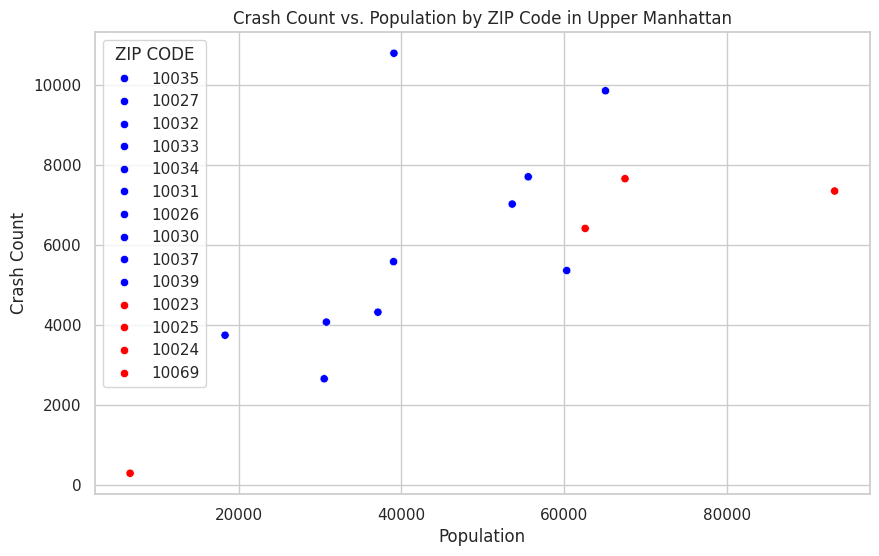

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


combined_df = pd.concat([upper_manhattan_merged_df, uws_merged_df])

colors = ['red' if zip_code in uws_zip_codes else 'blue' for zip_code in combined_df['ZIP CODE']]


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Population', y='Crash Count', data=combined_df, hue='ZIP CODE', palette=dict(zip(combined_df['ZIP CODE'].unique(), colors)))
plt.title('Crash Count vs. Population by ZIP Code in Upper Manhattan')
plt.xlabel('Population')
plt.ylabel('Crash Count')
plt.show()

In [ ]:

uws_merged_df['Crashes per 1000 People'] = (uws_merged_df['Crash Count'] / uws_merged_df['Population']) * 1000
print("Crashes per 1000 people in Upper West Side ZIP Codes:")
display(uws_merged_df[['ZIP CODE', 'Crashes per 1000 People']])


upper_manhattan_merged_df['Crashes per 1000 People'] = (upper_manhattan_merged_df['Crash Count'] / upper_manhattan_merged_df['Population']) * 1000
print("\nCrashes per 1000 people in the rest of Upper Manhattan ZIP Codes:")
display(upper_manhattan_merged_df[['ZIP CODE', 'Crashes per 1000 People']])

Crashes per 1000 people in Upper West Side ZIP Codes:


,ZIP CODE,Crashes per 1000 People
0,10023,113.594593
1,10025,78.896839
2,10024,102.595244
3,10069,44.384465



Crashes per 1000 people in the rest of Upper Manhattan ZIP Codes:


,ZIP CODE,Crashes per 1000 People
0,10035,276.367637
1,10027,151.579886
2,10032,138.739452
3,10033,131.111153
4,10034,143.146246
5,10031,88.981013
6,10026,116.535985
7,10030,132.451837
8,10037,204.494627
9,10039,87.146041


##<font color='crimson'>**Milestone #6 - Virtual Poster Board Creation: Data Storytelling**</font>

GOAL: The main goal of this milestone is to create a one page, virtual poster board to portray your research findings and recommendations! Your poster may be shared with the Department of Transportation and Federal Highway Authority.

/tmp/ipykernel_785/2894927725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ZIP CODE', y='Crashes per 1000 People', data=upper_manhattan_merged_df, palette='viridis')


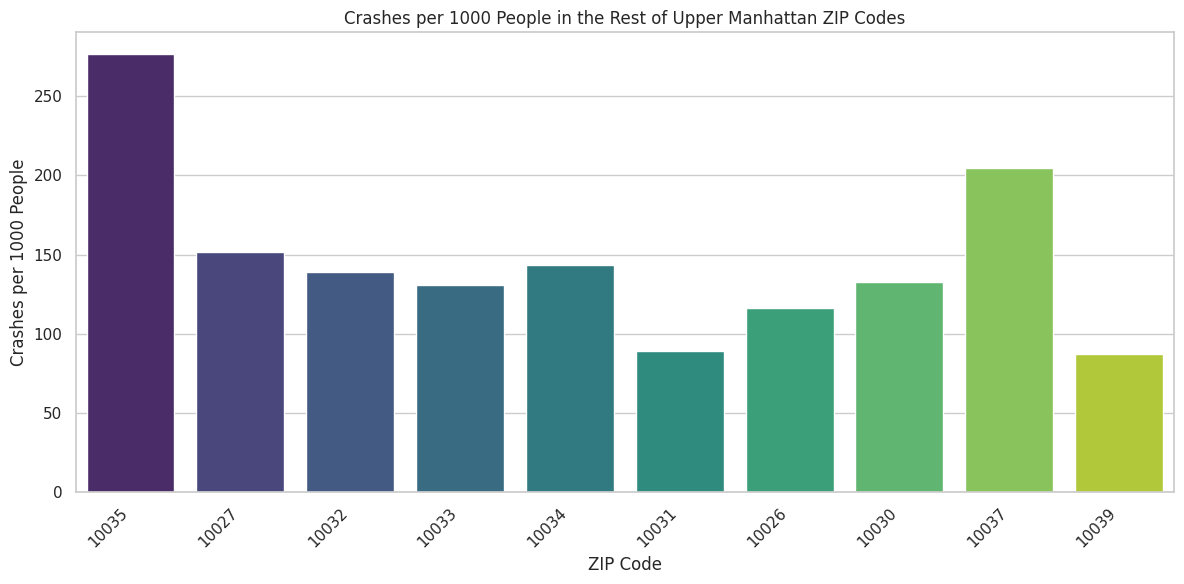

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='ZIP CODE', y='Crashes per 1000 People', data=upper_manhattan_merged_df, palette='viridis')
plt.title('Crashes per 1000 People in the Rest of Upper Manhattan ZIP Codes')
plt.xlabel('ZIP Code')
plt.ylabel('Crashes per 1000 People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_785/3188674547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ZIP CODE', y='Crashes per 1000 People', data=uws_merged_df, palette='viridis')


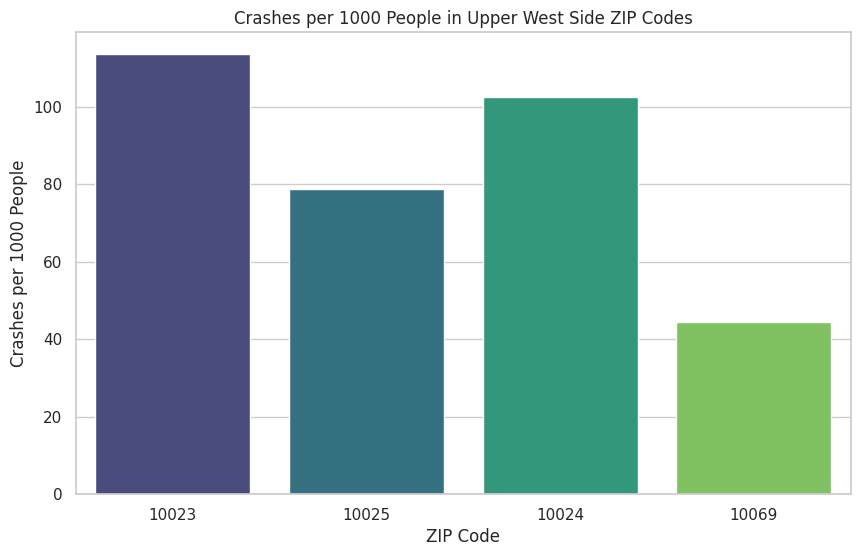

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='ZIP CODE', y='Crashes per 1000 People', data=uws_merged_df, palette='viridis')
plt.title('Crashes per 1000 People in Upper West Side ZIP Codes')
plt.xlabel('ZIP Code')
plt.ylabel('Crashes per 1000 People')
plt.show()

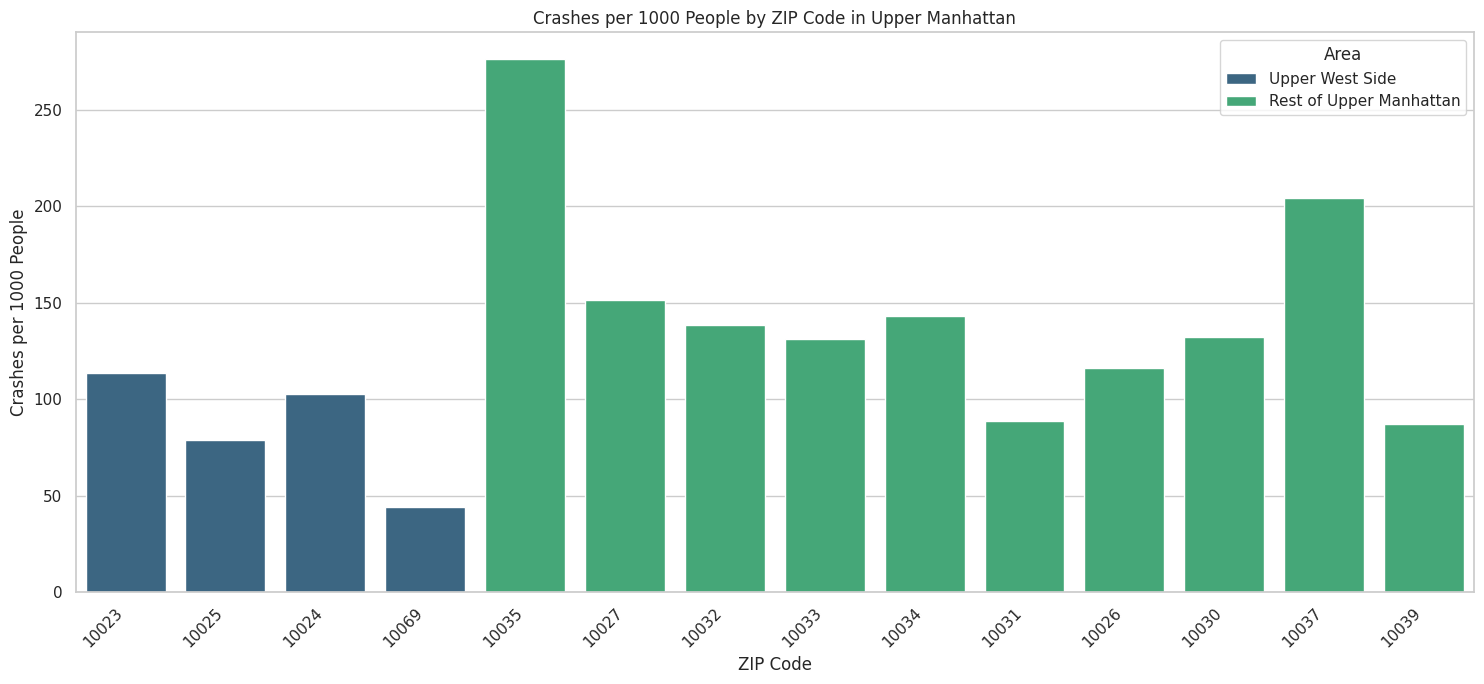

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

uws_merged_df['Area'] = 'Upper West Side'
upper_manhattan_merged_df['Area'] = 'Rest of Upper Manhattan'


combined_crashes_df = pd.concat([uws_merged_df, upper_manhattan_merged_df])

plt.figure(figsize=(15, 7))
sns.barplot(x='ZIP CODE', y='Crashes per 1000 People', hue='Area', data=combined_crashes_df, palette='viridis')
plt.title('Crashes per 1000 People by ZIP Code in Upper Manhattan')
plt.xlabel('ZIP Code')
plt.ylabel('Crashes per 1000 People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusion**

Although it initially appeared that the Upper West Side had a higher rate of crashes than Upper Manhattan, a closer look shows that Upper Manhattan has a higher rate. When broken down population-wise, the leading zip codes are all in Upper Manhattan.


## 🚗<font color='crimson'> **Thank you for completing the project!**</font> 🚗

We are one step closer to making roads safer for all. [Please submit all materials to the NSDC HQ team](https://docs.google.com/forms/d/e/1FAIpQLSeX1OSHj58EQs4ypFEPB_SH3OpWZeo67yU0WWOPVSqYtDrpWg/viewform) in order to receive a certificate of completion. Do reach out to us if you have any questions or concerns. We are here to help you learn and grow.
